# 7. Transformers y NLP con spaCy 🤖

En este notebook aprenderás los fundamentos del procesamiento de lenguaje natural (NLP) moderno usando **spaCy** — sin necesidad de cuenta ni token en ningún servicio externo.

✨ **Highlights:**
- Tokenización, POS tagging y reconocimiento de entidades (NER)
- Análisis de sentimientos con TextBlob
- Mapa de similitud entre tokens (análogo visual a la atención)
- Visualización de dependencias sintácticas con displaCy
- Embeddings de frases con PCA — sin ninguna API externa

## Objetivo
- Comprender la arquitectura de un pipeline NLP moderno (spaCy).
- Aplicar tokenización, POS tagging y NER a textos reales.
- Analizar sentimientos con TextBlob integrado en el pipeline.
- Visualizar similitudes entre tokens como análogo a la atención.
- Construir y comparar embeddings de frases con PCA.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado el [notebook 06 (RNN/LSTM)](./06_redes_recurrentes_rnn_lstm.ipynb).

- Conceptos de redes neuronales y procesamiento de secuencias.

> ⚠️ **Instalación previa** (ejecutar una sola vez en la terminal):
> ```bash
> pip install spacy textblob spacytextblob
> python -m spacy download en_core_web_md
> python -m textblob.download_corpora
> ```
> - `en_core_web_md` (~43 MB): modelo con vectores GloVe de 300 dims — **no requiere cuenta ni token**.
> - Para mayor calidad usa `en_core_web_lg` (~750 MB) — misma instalación.

## 1. Introducción teórica

### ¿Qué es un pipeline NLP?

Un pipeline NLP aplica una serie de componentes en cadena sobre el texto. spaCy lo implementa de forma eficiente y modular:

```
Texto crudo → Tokenizer → Tagger (POS) → Parser (dep.) → NER → Vectorizer → Doc
```

Cada componente enriquece el objeto `Doc` con anotaciones lingüísticas.

### Vectores de palabras y atención

Los modelos modernos representan cada palabra como un **vector en un espacio de alta dimensión** (GloVe, Word2Vec, fastText). La similitud coseno entre vectores refleja relaciones semánticas — de forma análoga a cómo la atención en los Transformers pondera qué tokens son relevantes entre sí.

| Concepto | Transformers | spaCy / GloVe |
|---------|-------------|---------------|
| Representación | Embedding contextual (BERT) | Embedding estático (GloVe 300d) |
| Relaciones | Matriz de atención | Similitud coseno entre vectores |
| Entidades | Clasificador de tokens | NER pipeline integrado |
| Ventaja | Contexto dinámico | Sin token, sin internet en inferencia |

### Modelos de spaCy disponibles

| Modelo | Tamaño | Vectores | Velocidad |
|--------|--------|----------|-----------|
| `en_core_web_sm` | 12 MB | No (solo hashes) | ⚡⚡⚡ |
| `en_core_web_md` | 43 MB | GloVe 300d (20K) | ⚡⚡ |
| `en_core_web_lg` | 750 MB | GloVe 300d (685K) | ⚡ |

## 2. Importación y carga de modelos

In [1]:
import random
import numpy as np
import time

# === Reproducibilidad ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Verificar spaCy
try:
    import spacy
    print(f'spaCy {spacy.__version__} ✅')
except ImportError:
    raise ImportError('Instala spaCy: pip install spacy')

# Verificar TextBlob
try:
    from textblob import TextBlob
    print('TextBlob ✅')
except ImportError:
    raise ImportError('Instala TextBlob: pip install textblob')

# Cargar modelo con vectores (en_core_web_md)
MODEL_NAME = 'en_core_web_md'
try:
    nlp = spacy.load(MODEL_NAME)
    print(f'Modelo "{MODEL_NAME}" cargado ✅')
    print(f'  Pipeline: {nlp.pipe_names}')
    print(f'  Vectores: {nlp.vocab.vectors.shape[0]:,} palabras × {nlp.vocab.vectors.shape[1]} dims')
except OSError:
    raise OSError(
        f'Modelo no encontrado. Descárgalo con:\n'
        f'  python -m spacy download {MODEL_NAME}'
    )

print('─' * 50)

spaCy 3.8.14 ✅
TextBlob ✅
Modelo "en_core_web_md" cargado ✅
  Pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
  Vectores: 20,000 palabras × 300 dims
──────────────────────────────────────────────────


## 3. Pipeline NLP: tokenización, POS y NER

spaCy procesa texto en un solo llamado `nlp(texto)` y enriquece cada token con sus anotaciones lingüísticas.

In [2]:
import pandas as pd

sentence = "Apple is looking at buying U.K. startup for $1 billion in London."
doc = nlp(sentence)

# Tabla de tokens con sus anotaciones
rows = []
for token in doc:
    rows.append({
        'Token':      token.text,
        'Lema':       token.lemma_,
        'POS':        token.pos_,
        'Etiqueta':   token.tag_,
        'Dep.':       token.dep_,
        'Stop word':  token.is_stop,
        'Vector?':    token.has_vector,
    })

df_tokens = pd.DataFrame(rows)
print(f'Frase: "{sentence}"\n')
print(df_tokens.to_string(index=False))

print(f'\n📍 Entidades nombradas (NER):')
for ent in doc.ents:
    print(f'  [{ent.label_:10s}] {ent.text!r:30s} — {spacy.explain(ent.label_)}')

Frase: "Apple is looking at buying U.K. startup for $1 billion in London."

  Token    Lema   POS Etiqueta     Dep.  Stop word  Vector?
  Apple   Apple PROPN      NNP    nsubj      False     True
     is      be   AUX      VBZ      aux       True     True
looking    look  VERB      VBG     ROOT      False     True
     at      at   ADP       IN     prep       True     True
 buying     buy  VERB      VBG    pcomp      False     True
   U.K.    U.K. PROPN      NNP compound      False     True
startup startup  NOUN       NN     dobj      False     True
    for     for   ADP       IN     prep       True     True
      $       $   SYM        $ quantmod      False     True
      1       1   NUM       CD compound      False     True
billion billion   NUM       CD     pobj      False     True
     in      in   ADP       IN     prep       True     True
 London  London PROPN      NNP     pobj      False     True
      .       . PUNCT        .    punct      False     True

📍 Entidades nombradas (

## 4. Análisis de sentimientos con TextBlob

TextBlob asigna a cada texto una **polaridad** (−1 negativo → +1 positivo) y una **subjetividad** (0 objetivo → 1 subjetivo).

😊 [POSITIVO] pol=+0.61  subj=0.75  →  I love machine learning! It's absolutely amazing.
😞 [NEGATIVO] pol=-1.00  subj=1.00  →  This movie was terrible and boring.
😐 [NEUTRAL ] pol=+0.00  subj=0.00  →  Transformers are revolutionizing NLP.
😊 [POSITIVO] pol=+0.43  subj=0.54  →  The weather today is okay, nothing special.
😞 [NEGATIVO] pol=-0.20  subj=0.45  →  The results were disappointing after so much effort.
😊 [POSITIVO] pol=+0.30  subj=0.72  →  What a fantastic product — highly recommend it!


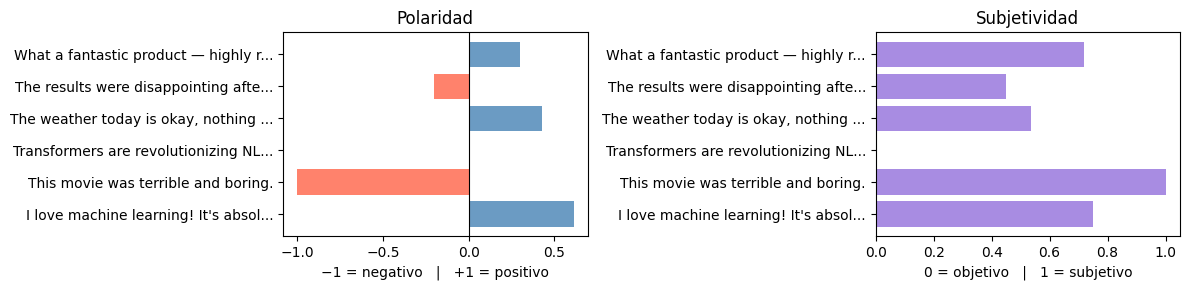

In [3]:
texts = [
    "I love machine learning! It's absolutely amazing.",
    "This movie was terrible and boring.",
    "Transformers are revolutionizing NLP.",
    "The weather today is okay, nothing special.",
    "The results were disappointing after so much effort.",
    "What a fantastic product — highly recommend it!",
]

results = []
for text in texts:
    blob = TextBlob(text)
    pol = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    if pol > 0.1:
        label, emoji = 'POSITIVO', '😊'
    elif pol < -0.1:
        label, emoji = 'NEGATIVO', '😞'
    else:
        label, emoji = 'NEUTRAL', '😐'
    results.append({'text': text, 'label': label, 'emoji': emoji,
                    'polarity': pol, 'subjectivity': subj})
    print(f'{emoji} [{label:8s}] pol={pol:+.2f}  subj={subj:.2f}  →  {text[:55]}')

# Gráfico de polaridad y subjetividad
df_sent = pd.DataFrame(results)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
colors = ['tomato' if l == 'NEGATIVO' else 'steelblue' if l == 'POSITIVO' else 'gray'
          for l in df_sent['label']]
labels_short = [t[:35] + '...' if len(t) > 35 else t for t in df_sent['text']]

axes[0].barh(labels_short, df_sent['polarity'], color=colors, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Polaridad')
axes[0].set_xlabel('−1 = negativo   |   +1 = positivo')

axes[1].barh(labels_short, df_sent['subjectivity'], color='mediumpurple', alpha=0.8)
axes[1].set_title('Subjetividad')
axes[1].set_xlabel('0 = objetivo   |   1 = subjetivo')

plt.tight_layout()
plt.show()

## 4b. Árbol de dependencias sintácticas (displaCy)

El parser de dependencias de spaCy construye un árbol sintáctico: cada token apunta a su **cabeza** (head) con una relación gramatical (sujeto, objeto, modificador...). Esto es análogo a cómo la atención en Transformers relaciona tokens entre sí.

In [4]:
from spacy import displacy

dep_sentence = "Transformers are changing deep learning and NLP forever."
doc_dep = nlp(dep_sentence)

# displaCy renderiza el árbol de dependencias en Jupyter de forma nativa
displacy.render(doc_dep, style='dep', jupyter=True,
                options={'compact': True, 'distance': 100})

# Tabla de relaciones
print(f'\nFrase: "{dep_sentence}"\n')
print(f'{"Token":<18} {"Dep.":<12} {"Cabeza":<18} {"Hijos"}')
print('─' * 65)
for token in doc_dep:
    children = [c.text for c in token.children]
    print(f'{token.text:<18} {token.dep_:<12} {token.head.text:<18} {children}')


Frase: "Transformers are changing deep learning and NLP forever."

Token              Dep.         Cabeza             Hijos
─────────────────────────────────────────────────────────────────
Transformers       nsubj        changing           []
are                aux          changing           []
changing           ROOT         changing           ['Transformers', 'are', 'learning', 'forever', '.']
deep               amod         learning           []
learning           dobj         changing           ['deep', 'and', 'NLP']
and                cc           learning           []
NLP                conj         learning           []
forever            advmod       changing           []
.                  punct        changing           []


## 5. Mapa de similitud entre tokens (análogo a la atención)

La similitud coseno entre los vectores GloVe de los tokens muestra qué palabras son semánticamente cercanas — la misma información que visualiza la matriz de atención en BERT.

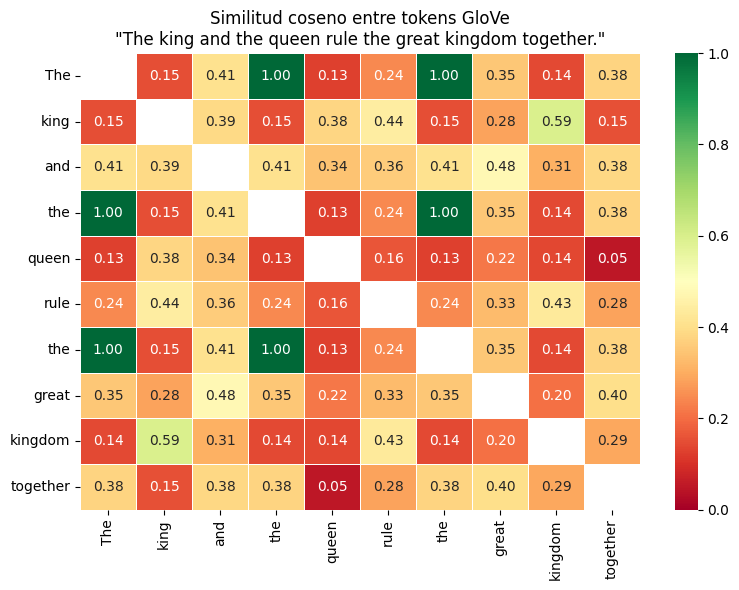

💡 Par más similar: "The" ↔ "the"  (similitud = 1.000)


In [5]:
sim_sentence = "The king and the queen rule the great kingdom together."
doc_sim = nlp(sim_sentence)

# Filtrar solo tokens con vectores (excluir puntuación y stop words sin vector)
tokens_vec = [t for t in doc_sim if t.has_vector and not t.is_punct]
labels = [t.text for t in tokens_vec]
n = len(tokens_vec)

# Construir matriz de similitud coseno
sim_matrix = np.zeros((n, n))
for i, ti in enumerate(tokens_vec):
    for j, tj in enumerate(tokens_vec):
        sim_matrix[i, j] = ti.similarity(tj)

plt.figure(figsize=(8, 6))
mask = np.eye(n, dtype=bool)  # ocultar diagonal (similitud consigo mismo = 1)
sns.heatmap(sim_matrix, xticklabels=labels, yticklabels=labels,
            cmap='RdYlGn', vmin=0, vmax=1, annot=True, fmt='.2f',
            linewidths=0.5, mask=mask)
plt.title(f'Similitud coseno entre tokens GloVe\n"{sim_sentence}"')
plt.tight_layout()
plt.show()

# Destacar el par más similar (fuera de la diagonal)
sim_copy = sim_matrix.copy()
np.fill_diagonal(sim_copy, -1)
idx = np.unravel_index(sim_copy.argmax(), sim_copy.shape)
print(f'💡 Par más similar: "{labels[idx[0]]}" ↔ "{labels[idx[1]]}"  '
      f'(similitud = {sim_matrix[idx]:.3f})')

## 6. Embeddings de frases con PCA

Cada frase tiene un vector resumen (`doc.vector`) que es el promedio de los vectores de sus tokens. Con PCA lo proyectamos a 2D para ver cómo se agrupan frases semánticamente similares.

Embeddings calculados en 44.7 ms  |  shape: (8, 300)


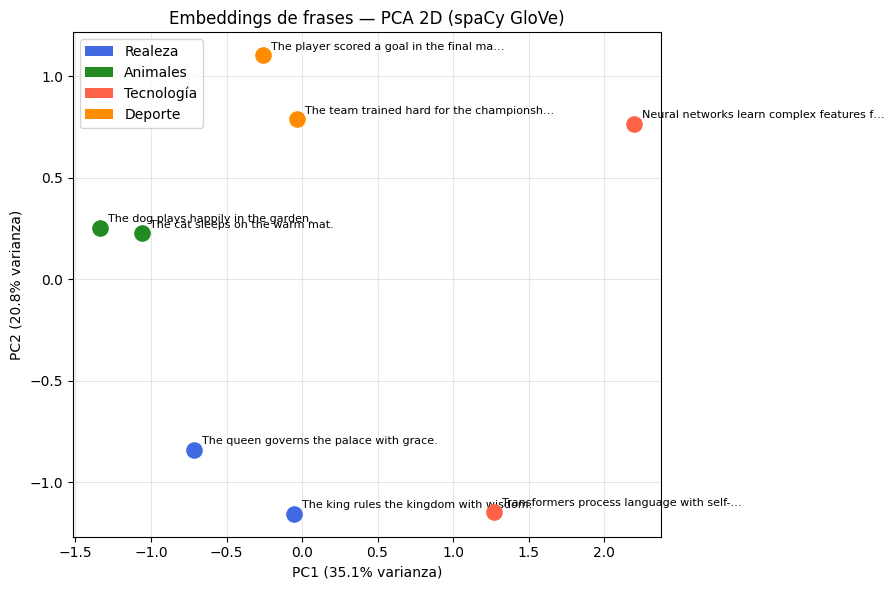

💡 Varianza explicada total: 55.9%
Las frases de la misma categoría semántica se agrupan en el espacio de embeddings.

📊 Similitud coseno promedio entre categorías:
  "The king rules the kingdom wit…" ↔ "Neural networks learn complex …"  →  0.648
  "The king rules the kingdom wit…" ↔ "Transformers process language …"  →  0.710
  "The queen governs the palace w…" ↔ "Neural networks learn complex …"  →  0.576
  "The queen governs the palace w…" ↔ "Transformers process language …"  →  0.683


In [6]:
sentences = [
    # Realeza
    "The king rules the kingdom with wisdom.",
    "The queen governs the palace with grace.",
    # Animales
    "The cat sleeps on the warm mat.",
    "The dog plays happily in the garden.",
    # Tecnología / IA
    "Neural networks learn complex features from data.",
    "Transformers process language with self-attention.",
    # Deporte
    "The player scored a goal in the final match.",
    "The team trained hard for the championship.",
]

categories = ['Realeza', 'Realeza', 'Animales', 'Animales',
              'Tecnología', 'Tecnología', 'Deporte', 'Deporte']
palette = {'Realeza': 'royalblue', 'Animales': 'forestgreen',
           'Tecnología': 'tomato', 'Deporte': 'darkorange'}

# Obtener embeddings de frases
start = time.time()
vectors = np.array([nlp(s).vector for s in sentences])
t_embed = time.time() - start
print(f'Embeddings calculados en {t_embed*1000:.1f} ms  |  shape: {vectors.shape}')

# Reducción a 2D con PCA
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(vectors)

# Visualización
fig, ax = plt.subplots(figsize=(9, 6))
for i, (x, y) in enumerate(coords):
    cat = categories[i]
    ax.scatter(x, y, s=120, c=palette[cat], zorder=3)
    ax.annotate(sentences[i][:40] + '…' if len(sentences[i]) > 40 else sentences[i],
                (x, y), textcoords='offset points', xytext=(6, 4), fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_elements, loc='best')
ax.set_title('Embeddings de frases — PCA 2D (spaCy GloVe)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'💡 Varianza explicada total: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print('Las frases de la misma categoría semántica se agrupan en el espacio de embeddings.')

# Similaridades entre categorías
print('\n📊 Similitud coseno promedio entre categorías:')
for s1 in sentences[:2]:
    for s2 in sentences[4:6]:
        sim = nlp(s1).similarity(nlp(s2))
        print(f'  "{s1[:30]}…" ↔ "{s2[:30]}…"  →  {sim:.3f}')

## 7. Reconocimiento de entidades nombradas (NER)

El NER identifica automáticamente personas, organizaciones, lugares, fechas, cantidades, etc. Es una de las tareas donde spaCy destaca frente a soluciones más simples.


📝 "Elon Musk founded SpaceX in 2002 and Tesla in Palo Alto, California."
   [PERSON    ] 'Elon Musk'  — People, including fictional
   [ORG       ] 'SpaceX'  — Companies, agencies, institutions, etc.
   [DATE      ] '2002'  — Absolute or relative dates or periods
   [GPE       ] 'Tesla'  — Countries, cities, states
   [GPE       ] 'Palo Alto'  — Countries, cities, states
   [GPE       ] 'California'  — Countries, cities, states

📝 "The European Central Bank raised interest rates by 25 basis points in Frankfurt on Thursday."
   [ORG       ] 'The European Central Bank'  — Companies, agencies, institutions, etc.
   [CARDINAL  ] '25'  — Numerals that do not fall under another type
   [GPE       ] 'Frankfurt'  — Countries, cities, states
   [DATE      ] 'Thursday'  — Absolute or relative dates or periods

📝 "OpenAI released GPT-4 in March 2023, just months after ChatGPT launched in San Francisco."
   [GPE       ] 'OpenAI'  — Countries, cities, states
   [PERSON    ] 'GPT-4'  — People, incl

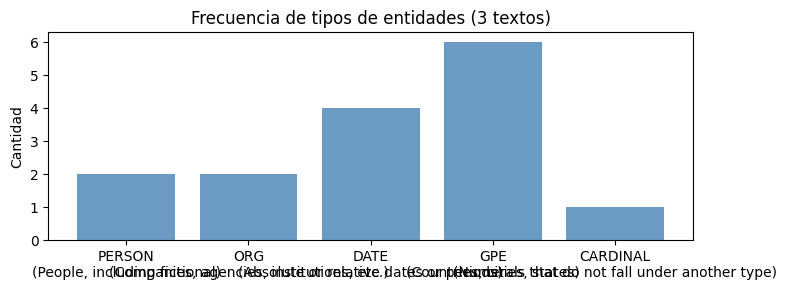

In [7]:
ner_texts = [
    "Elon Musk founded SpaceX in 2002 and Tesla in Palo Alto, California.",
    "The European Central Bank raised interest rates by 25 basis points in Frankfurt on Thursday.",
    "OpenAI released GPT-4 in March 2023, just months after ChatGPT launched in San Francisco.",
]

for text in ner_texts:
    doc_ner = nlp(text)
    print(f'\n📝 "{text}"')
    for ent in doc_ner.ents:
        print(f'   [{ent.label_:10s}] {ent.text!r}  — {spacy.explain(ent.label_)}')

# Visualización con displaCy (renderiza con colores por tipo de entidad)
print('\n' + '─'*60)
print('Visualización displaCy NER:\n')
for text in ner_texts:
    doc_ner = nlp(text)
    displacy.render(doc_ner, style='ent', jupyter=True)

# Frecuencia de tipos de entidades en los tres textos
from collections import Counter
all_ents = [ent.label_ for text in ner_texts for ent in nlp(text).ents]
counter = Counter(all_ents)

fig, ax = plt.subplots(figsize=(8, 3))
labels_ner = [f'{l}\n({spacy.explain(l)})' for l in counter.keys()]
ax.bar(labels_ner, counter.values(), color='steelblue', alpha=0.8)
ax.set_title('Frecuencia de tipos de entidades (3 textos)')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

### Recomendaciones prácticas para spaCy y NLP

| Aspecto | Recomendación |
|---------|---------------|
| **Modelo a elegir** | `md` para desarrollo con vectores; `lg` para mayor calidad en producción |
| **Sin vectores** | `sm` solo sirve para POS/NER; no usar `doc.similarity()` con él |
| **Pipeline** | Deshabilitar componentes no necesarios: `nlp("texto", disable=["ner"])` |
| **Batch processing** | Usar `nlp.pipe(textos, batch_size=64)` para procesar miles de textos eficientemente |
| **Similitud** | `doc.similarity()` usa la media de vectores de tokens — buena aproximación, no perfecta |
| **Sentiment** | TextBlob es simple; para producción considera entrenar un `textcat` con datos propios |
| **Entidades personalizadas** | Usa `nlp.add_pipe("entity_ruler")` para agregar entidades de dominio sin re-entrenar |
| **Escalado** | spaCy procesa ~100K palabras/segundo en CPU — ideal para pipelines de producción |

> 💡 **Truco:** Si necesitas Transformers (BERT, RoBERTa) sin HF Hub, usa `en_core_web_trf`:
> ```bash
> pip install spacy-transformers
> python -m spacy download en_core_web_trf
> ```
> Descarga el modelo transformer directamente — sin cuenta ni token.

## 8. Discusión y Conclusiones

**¿Qué aprendimos?**

- **spaCy** proporciona un pipeline NLP completo (tokenización, POS, dependencias, NER, vectores) en una sola librería sin ningún token externo.
- El **árbol de dependencias** muestra las relaciones gramaticales entre palabras — análogo conceptual a la matriz de atención de los Transformers.
- La **similitud coseno entre vectores GloVe** reproduce el comportamiento de las cabezas de atención: detecta qué tokens son semánticamente cercanos.
- El análisis PCA de embeddings de frases confirma que las frases del mismo dominio semántico se agrupan naturalmente — sin supervisión.
- **TextBlob** ofrece sentiment rápido y suficiente para prototipado; para producción, entrenar un `textcat` propio con datos del dominio.
- **displaCy** permite visualizar NER y dependencias directamente en el notebook sin ninguna librería adicional.

**Comparativa con HuggingFace:**
| Aspecto | spaCy + GloVe | HuggingFace + BERT |
|---------|---------------|--------------------|
| Token/cuenta | No ❌ | No (modelos públicos) ✅ |
| Contexto | Estático | Dinámico (contextual) |
| Velocidad | ⚡⚡⚡ | ⚡ |
| Facilidad | Alta | Media |
| Calidad sentiment | Buena | Excelente |

En el siguiente notebook exploraremos **GANs** para generación de datos sintéticos.

## 9. Ejercicios Propuestos

1. **Ejercicio 1:** Usa `nlp.pipe()` para procesar una lista de 100 textos generados aleatoriamente. Mide el tiempo y compáralo con un bucle `nlp(text)` simple.

2. **Ejercicio 2:** Filtra los tokens de una frase compleja dejando solo sustantivos y verbos (POS = `NOUN`, `VERB`). Construye un resumen simplificado de la frase.

3. **Ejercicio 3:** Usa la similitud de `doc.similarity()` para ordenar una lista de frases por cercanía semántica a una frase de referencia. Visualiza el ranking.

4. **Ejercicio 4 (Avanzado):** Agrega un `entity_ruler` personalizado al pipeline para detectar entidades de un dominio específico (e.g., nombres de modelos de IA: "GPT-4", "BERT", "LLaMA"). Compara con la detección NER por defecto.

## 10. Referencias y Recursos

- [spaCy Documentation](https://spacy.io/usage)
- [spaCy Models & Languages](https://spacy.io/models/en)
- [displaCy Visualizer](https://explosion.ai/demos/displacy)
- [TextBlob Documentation](https://textblob.readthedocs.io/)
- [spaCy 101 — Conceptos clave](https://spacy.io/usage/spacy-101)
- Vaswani et al. (2017). *Attention is All You Need.* (arquitectura Transformer)
- Pennington et al. (2014). *GloVe: Global Vectors for Word Representation.*

---

📎 **Notebook anterior:** [06. Redes Recurrentes (RNN/LSTM)](./06_redes_recurrentes_rnn_lstm.ipynb)  
📎 **Notebook siguiente:** [08. Redes Generativas (GANs)](./08_gans.ipynb)